**First Project:** *SACCO DATA ANALYSIS*

**Student name:** *Omondi Terry Wawuye*

**Admission Number:** *26/04122*

**Submission deadline:** *Friday 3rd July, 2026*


**0.  SETUP: INSTALL LIBRARIES AND CONFIGURE CHAT STYLES**

In [22]:
#importinng the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Configuring chart styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

**1. LOAD DATA: MOUNT GOOGLE DRIVE, LOAD CSV, fIRST INSPECTION**

In [24]:
# Mount my google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
#importing the accual project file
path= '/content/drive/My Drive/Colab Notebooks/'
Sacco_data= pd.read_csv(path+'sacco_data.csv')
# saving my path so i dont have to type the whole path all over again

In [26]:
# Checking if the data is successfully mounted
#head function only show the 1st 5
Sacco_data.head()

,Member_ID,County,Gender,Age,Marital_Status,Education_Level,Business_Type,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Purpose,Loan_Status,Loan_Income_Ratio,Savings_Rate,Total_Assets
0,SACCO-1001,Kisumu,Male,40,Married,Certificate,Farming,15,5,47182,12381,91713,Business Expansion,Defaulted,1.9438,0.2624,36197
1,SACCO-1002,Mombasa,Female,57,Married,Certificate,Farming,36,1,65904,7303,0,NaN,No Loan,0.0000,0.1108,47998
2,SACCO-1003,Nakuru,Male,29,Married,Diploma,Transport,6,2,61223,6975,109108,Emergency,Performing,1.7821,0.1139,26677
3,SACCO-1004,Mombasa,Male,50,Single,Primary,Manufacturing,30,2,71782,21742,0,NaN,No Loan,0.0000,0.3029,46984
4,SACCO-1005,Mombasa,Male,53,Married,Certificate,Farming,61,3,62505,17805,86518,Emergency,Performing,1.3842,0.2849,73646


In [27]:
# Checking data shape
print(Sacco_data.shape)
# Checking dtype
print(Sacco_data.dtypes)
# Description
Sacco_data.describe()

(200, 17)
Member_ID             object
County                object
Gender                object
Age                    int64
Marital_Status        object
Education_Level       object
Business_Type         object
Months_As_Member       int64
Dependants             int64
Monthly_Income         int64
Savings                int64
Loan_Amount            int64
Loan_Purpose          object
Loan_Status           object
Loan_Income_Ratio    float64
Savings_Rate         float64
Total_Assets           int64
dtype: object


,Age,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Income_Ratio,Savings_Rate,Total_Assets
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,41.115000,42.615000,2.890000,63841.705000,17310.220000,132423.950000,2.053600,0.268880,66822.680000
std,11.843696,22.503529,2.031882,21799.572679,9499.777034,120066.064842,1.632241,0.102904,30842.495559
min,22.000000,3.000000,0.000000,15000.000000,5000.000000,0.000000,0.000000,0.085000,9531.000000
25%,31.000000,23.000000,1.000000,49576.500000,9461.000000,0.000000,0.000000,0.186350,38307.250000
50%,41.000000,42.000000,3.000000,62354.500000,15929.500000,113906.500000,2.025800,0.267100,68084.500000
75%,52.000000,63.000000,5.000000,77567.750000,23496.500000,213436.750000,3.346100,0.355800,91599.750000
max,61.000000,83.000000,6.000000,128571.000000,52824.000000,453244.000000,4.946900,0.448500,142109.000000


**Reflection questions
1. 200
2. 5
3. 63841.705000
4. Yes. 128571.0 is signoficantly higher than the others
5. Column that contains text:

   * Member Id
   * County
   * Gender
   * Marital Status
   * Education Level
   * Business Type  
   * Loan Purpose
   * Loan Status

   Columns that contains numbers
   * Age  
   * Months as members
   * Dependants
   * monthly Income
   * Savings
   * Loan Amounts  
   * Loan Icome Ratio
   * Savings Rates
   *   Total Assets








  

**2. CLEAN AND VALIDATE: CHECK FOR NULLS, DUPLICATES AND INVALID VALUES**

In [28]:
# Checking for missing data
Sacco_data.isnull().sum()

,0
Member_ID,0
County,0
Gender,0
Age,0
Marital_Status,0
Education_Level,0
Business_Type,0
Months_As_Member,0
Dependants,0
Monthly_Income,0


In [29]:
# only the loan_purpose column has missing values
# Filling missing text with the most used(mode)
Sacco_data['Loan_Purpose'] = Sacco_data['Loan_Purpose'].fillna(Sacco_data['Loan_Purpose'].mode()[0])

In [30]:
# checking for duplicates
Sacco_data.duplicated().sum()# no duplicates found

np.int64(0)

In [31]:
# Data after changes
Sacco_data.head()

,Member_ID,County,Gender,Age,Marital_Status,Education_Level,Business_Type,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Purpose,Loan_Status,Loan_Income_Ratio,Savings_Rate,Total_Assets
0,SACCO-1001,Kisumu,Male,40,Married,Certificate,Farming,15,5,47182,12381,91713,Business Expansion,Defaulted,1.9438,0.2624,36197
1,SACCO-1002,Mombasa,Female,57,Married,Certificate,Farming,36,1,65904,7303,0,Agricultural Input,No Loan,0.0000,0.1108,47998
2,SACCO-1003,Nakuru,Male,29,Married,Diploma,Transport,6,2,61223,6975,109108,Emergency,Performing,1.7821,0.1139,26677
3,SACCO-1004,Mombasa,Male,50,Single,Primary,Manufacturing,30,2,71782,21742,0,Agricultural Input,No Loan,0.0000,0.3029,46984
4,SACCO-1005,Mombasa,Male,53,Married,Certificate,Farming,61,3,62505,17805,86518,Emergency,Performing,1.3842,0.2849,73646


**Reflection questions
1. Yes, Loan purpose.
2. If not for Loan purpose, the data would be perfect
3. The average will drastically increase
4. The white space wastes storage and memory**

**3. FEATURE ENGINEER: CREATE RISK_TIER INCOME, INCOME_BAND, HAS_LOAN COLUMNS**

In [32]:
# Adding columns
#1. Risk tier( Categorise into low risk, Medium risk, High risk)
Sacco_data['Risk_Tier'] = np.where(Sacco_data['Loan_Income_Ratio'] > 2.0, 'High Risk',
                                   np.where(Sacco_data['Loan_Income_Ratio'] <= 1.0, 'Low Risk', 'Medium Risk'))
#2. Income Band
q25= Sacco_data['Monthly_Income'].quantile(0.25)
q75= Sacco_data['Monthly_Income'].quantile(0.75)
Sacco_data['Income_Band'] = np.where(Sacco_data['Monthly_Income'] <= q25, 'Low Income',
                                     np.where(Sacco_data['Monthly_Income'] <= q75, 'Middle Income', 'High Income'))
#3.  Has loan
Sacco_data['Has_Loan'] = np.where(Sacco_data['Loan_Amount'] > 0, 'Yes', 'No')

In [33]:
Sacco_data.to_csv(path+'cleaned_sacco_data.csv', index=False)# The false makes sure the the file doesn't  get saved with useless indexing because it will make my work messy
# checking for confirmation
Sacco_data.head()

,Member_ID,County,Gender,Age,Marital_Status,Education_Level,Business_Type,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Purpose,Loan_Status,Loan_Income_Ratio,Savings_Rate,Total_Assets,Risk_Tier,Income_Band,Has_Loan
0,SACCO-1001,Kisumu,Male,40,Married,Certificate,Farming,15,5,47182,12381,91713,Business Expansion,Defaulted,1.9438,0.2624,36197,Medium Risk,Low Income,Yes
1,SACCO-1002,Mombasa,Female,57,Married,Certificate,Farming,36,1,65904,7303,0,Agricultural Input,No Loan,0.0000,0.1108,47998,Low Risk,Middle Income,No
2,SACCO-1003,Nakuru,Male,29,Married,Diploma,Transport,6,2,61223,6975,109108,Emergency,Performing,1.7821,0.1139,26677,Medium Risk,Middle Income,Yes
3,SACCO-1004,Mombasa,Male,50,Single,Primary,Manufacturing,30,2,71782,21742,0,Agricultural Input,No Loan,0.0000,0.3029,46984,Low Risk,Middle Income,No
4,SACCO-1005,Mombasa,Male,53,Married,Certificate,Farming,61,3,62505,17805,86518,Emergency,Performing,1.3842,0.2849,73646,Medium Risk,Middle Income,Yes


**Reflection Quesions
1. Loan income ratio 1.5 fales under  Medium_Tier
2. Members with no loan are classified into the lowest possible risk tier because they pose no risk
3. low risk tier
4. Member_Loan_eligibility. Based on the years the member has stayed with the sacco, one can determine the member's eligibility for the loan he or she is asking for.**

**4. Exploratory Data Analysis**

In [34]:
# Showing Income by county
Sacco_data.groupby('County')['Monthly_Income'].mean().round(2)

,Monthly_Income
County,
Kiambu,71822.63
Kisumu,49946.10
Mombasa,64426.33
Nairobi,82493.40
Nakuru,52449.35


Nairobi has the wealthiest member

In [35]:
# Showing Default rate by county
Sacco_data.groupby('County')['Loan_Status'].apply(lambda x: (x=='Yes').sum()).sort_values(ascending=False)

,Loan_Status
County,
Kiambu,0
Kisumu,0
Mombasa,0
Nairobi,0
Nakuru,0


They all stand at zero

In [36]:
# Showing Saving rates by gender
Sacco_data.groupby('Gender')['Savings_Rate'].mean()

,Savings_Rate
Gender,
Female,0.277920
Male,0.260019


Females save a larger proportion of income

In [37]:
# Top business types
Sacco_data.groupby('Business_Type')['Monthly_Income'].sum().nlargest(3)

,Monthly_Income
Business_Type,
Services,2926028
Retail,2623886
Farming,2595588


Sectors that earn the most are service, retail and farming

In [38]:
# Showing risk vs loan status
pd.crosstab(Sacco_data['Risk_Tier'],Sacco_data['Loan_Status'])

Loan_Status,Defaulted,No Loan,Performing
Risk_Tier,,,
High Risk,21,0,80
Low Risk,3,54,11
Medium Risk,8,0,23


Yes it does because the number of high risk defaulted is significantly higher than low risk defaulted

Reflection Questions
  1. Cross tabulation displays a row by column grid whereas groupby displays stacked grouped data.
  2. Lack of sufficient income, hence delay in payment.
  3. monthly income and loan status

**5. Visualisation**

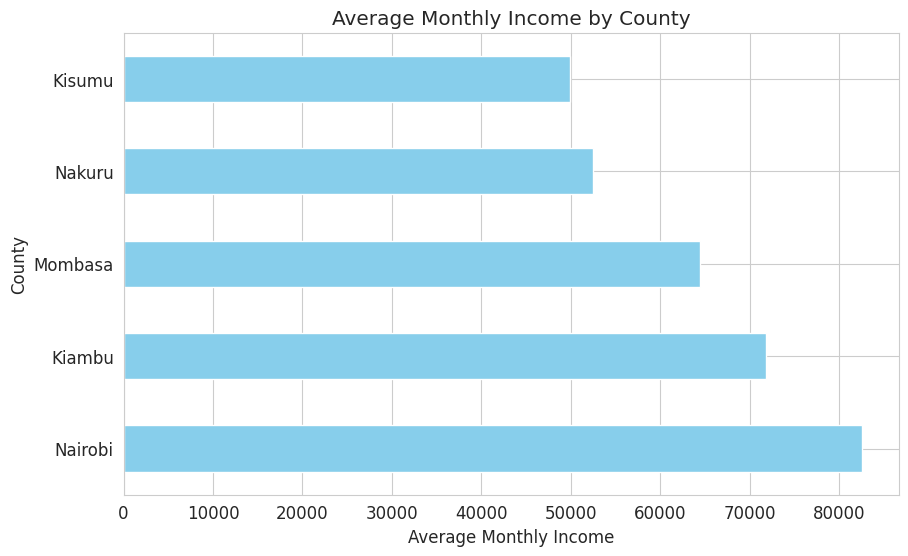

In [39]:
# Horizontal Bar graph
Sacco_data.groupby('County')['Monthly_Income'].mean().sort_values(ascending=False).plot(kind='barh', color='skyblue')
plt.xlabel('Average Monthly Income')
plt.ylabel('County')
plt.title('Average Monthly Income by County')
plt.show()

Nairobi has the highest average member income

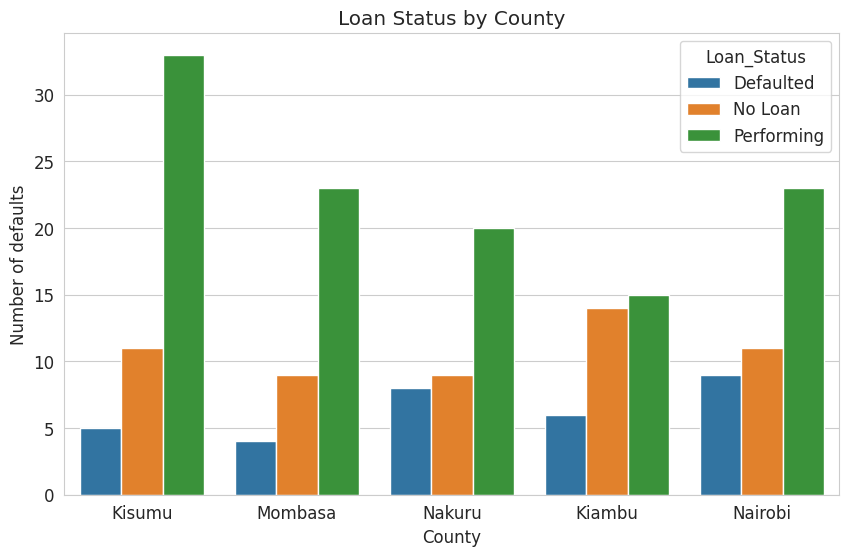

In [40]:
sns.countplot(x='County', hue='Loan_Status', data=Sacco_data)
plt.xlabel('County')
plt.ylabel('Number of defaults')
plt.title('Loan Status by County')
plt.show()

Loan defaults are highest in Nairobi

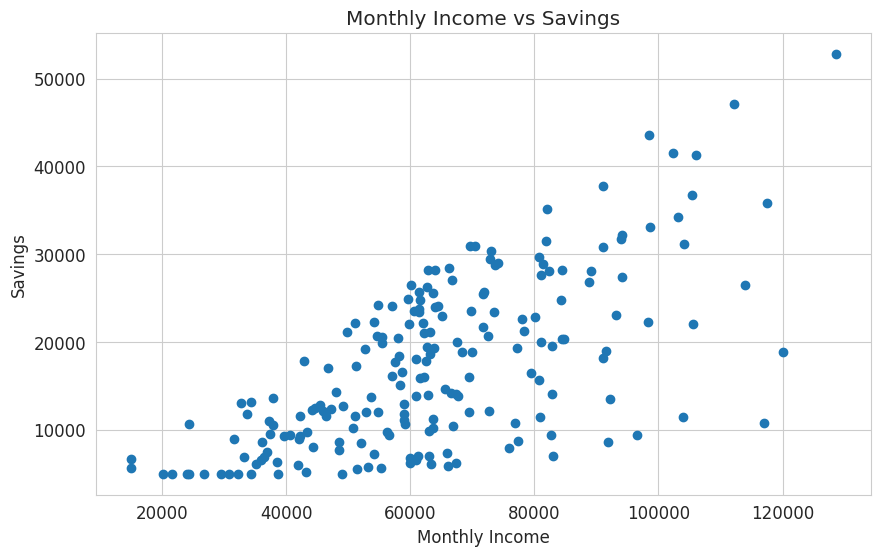

In [41]:
# Scatter plot using matplotlib
plt.scatter(Sacco_data['Monthly_Income'], Sacco_data['Savings'])
plt.xlabel('Monthly Income')
plt.ylabel('Savings')
plt.title('Monthly Income vs Savings')
plt.show()

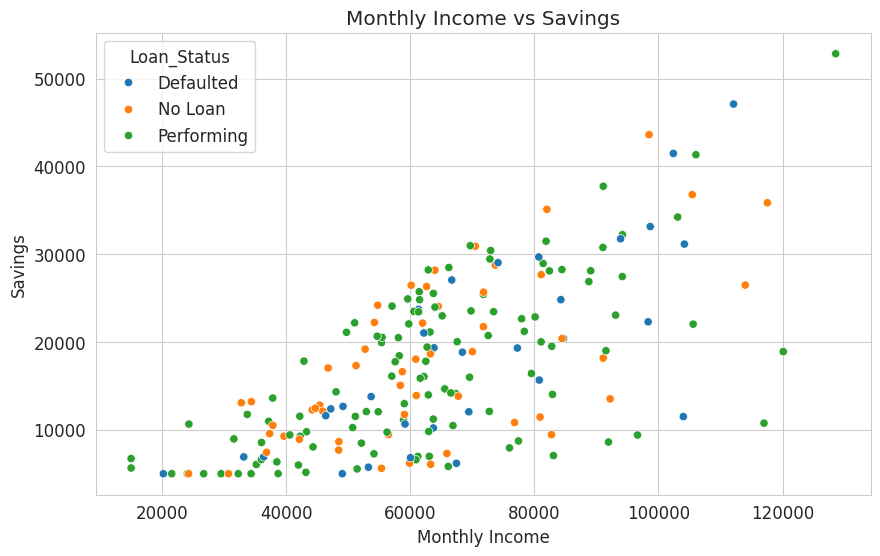

In [42]:
# Scatterplot using
sns.scatterplot(x='Monthly_Income', y='Savings',hue='Loan_Status' ,data=Sacco_data)
plt.xlabel('Monthly Income')
plt.ylabel('Savings')
plt.title('Monthly Income vs Savings')
plt.show()

From our chart it is seen that the higher the income, the higher the savings.

performing rate increases by increase in monthly income

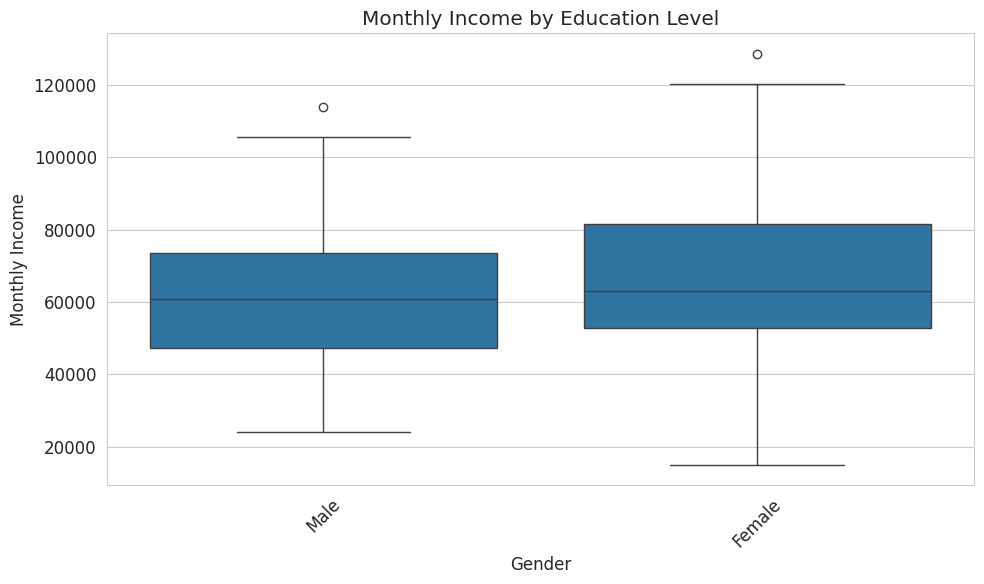

In [43]:
#Boxplot.
import seaborn as sns

# Box plot using seaborn for better handling of categorical data
sns.boxplot(x='Gender', y='Monthly_Income', data=Sacco_data)
plt.xlabel('Gender')
plt.ylabel('Monthly Income')
plt.title('Monthly Income by Education Level')
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Yes. The females earn slightly higher that the males.

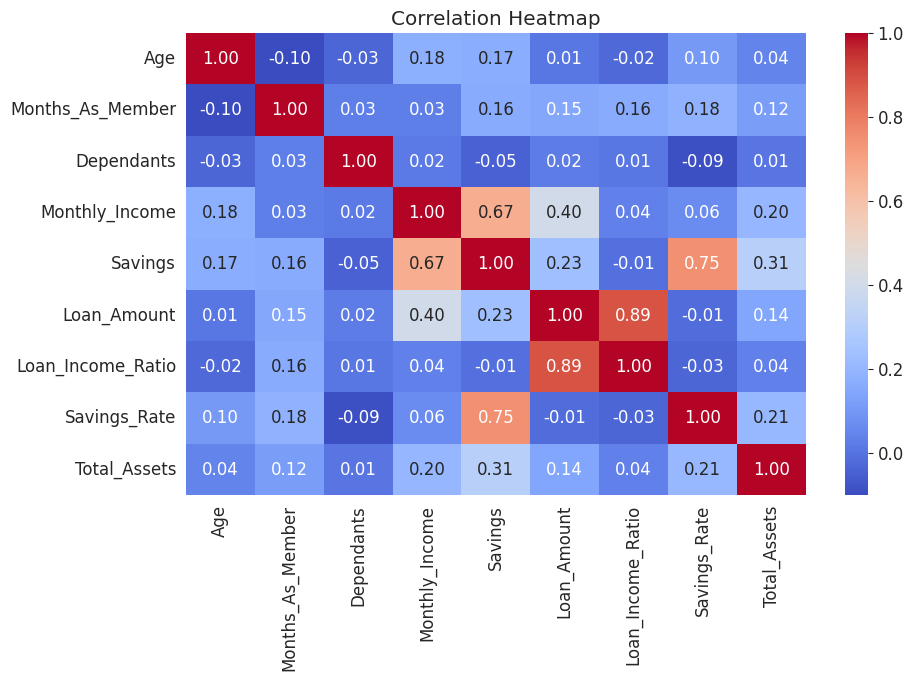

In [44]:
# Heatmap
# Select only numeric columns for correlation calculation
numeric_data = Sacco_data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Strongest positive correlation:
1. loan amounts and loan income ratio- Have vry strong corelation(0.89)
2. Savings and savings rate - Strong correlation (0.75)
3. Monthly income and savings - Strong correlation (0.67)
4. Monthly income and savings rate - Strong correlation (0.61).

Moderate positive correlation
1. Monthly income and loan amounts - Moderate correlation (0.40)
2. Savings and total assets- (0.31)
3. Monthly income and total assets - Mild correlation (0.20)

All other variable pairs show very weak or near zero correlation (values close to 00)

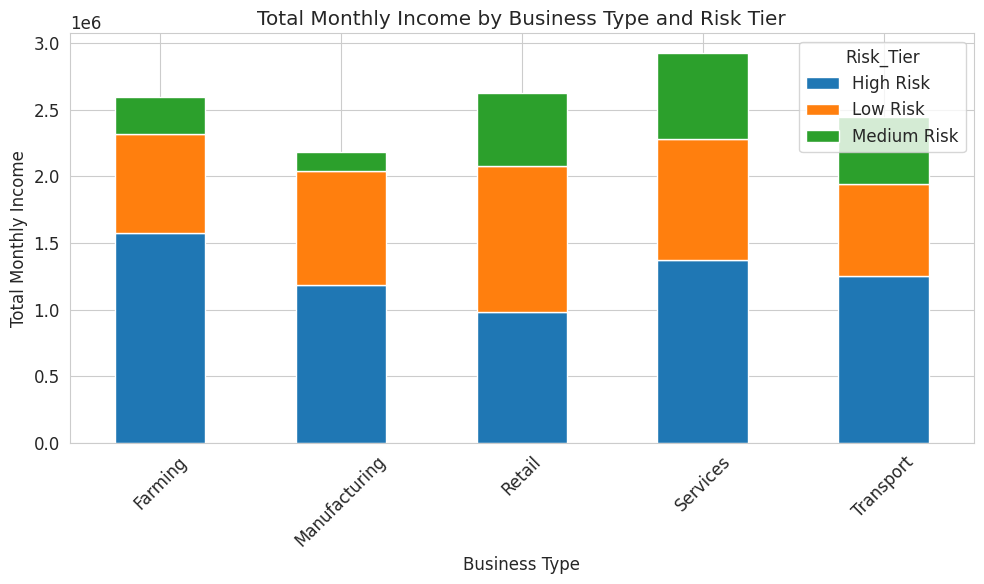

In [45]:
# Stacked bar
# Aggregate Monthly_Income by Loan_Status and Risk_Tier
df_stacked = Sacco_data.groupby(['Business_Type', 'Risk_Tier'])['Monthly_Income'].sum().unstack()

# Plotting the stacked bar chart
df_stacked.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Business Type')
plt.ylabel('Total Monthly Income')
plt.title('Total Monthly Income by Business Type and Risk Tier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Farming caries the most high risk members

**6. High risk member investigation**

In [46]:
#6.1: DataFrame of high risk members only
high_risk_members= Sacco_data[Sacco_data['Loan_Income_Ratio']>2]
display(high_risk_members)


,Member_ID,County,Gender,Age,Marital_Status,Education_Level,Business_Type,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Purpose,Loan_Status,Loan_Income_Ratio,Savings_Rate,Total_Assets,Risk_Tier,Income_Band,Has_Loan
6,SACCO-1007,Nakuru,Female,27,Married,Diploma,Farming,71,0,66214,28478,209097,Business Expansion,Performing,3.1579,0.4301,114141,High Risk,Middle Income,Yes
7,SACCO-1008,Nakuru,Male,39,Married,Certificate,Manufacturing,27,0,59766,22058,125761,Emergency,Performing,2.1042,0.3691,114822,High Risk,Middle Income,Yes
8,SACCO-1009,Nakuru,Male,40,Married,Degree,Manufacturing,5,4,32258,5000,125155,Emergency,Performing,3.8798,0.1550,58574,High Risk,Low Income,Yes
11,SACCO-1012,Nakuru,Female,53,Divorced,Diploma,Manufacturing,22,2,62898,28209,251996,Business Expansion,Performing,4.0064,0.4485,37380,High Risk,Middle Income,Yes
12,SACCO-1013,Mombasa,Male,24,Married,Diploma,Transport,36,5,49034,5000,155939,Emergency,Defaulted,3.1802,0.1020,103932,High Risk,Low Income,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,SACCO-1188,Nairobi,Female,40,Divorced,Diploma,Transport,47,0,91535,19010,386818,Agricultural Input,Performing,4.2259,0.2077,114112,High Risk,High Income,Yes
188,SACCO-1189,Nairobi,Male,32,Married,Degree,Retail,69,5,105598,22029,214103,Emergency,Performing,2.0275,0.2086,117348,High Risk,High Income,Yes
189,SACCO-1190,Nakuru,Male,22,Single,Degree,Services,68,3,67441,6188,264536,Agricultural Input,Defaulted,3.9225,0.0918,26771,High Risk,Middle Income,Yes
194,SACCO-1195,Kisumu,Female,36,Married,Diploma,Services,40,3,20190,5000,48645,Education,Defaulted,2.4094,0.2476,24456,High Risk,Low Income,Yes


In [47]:
#6.2: default percentage for high risk vs all members
defaulted_high_risk_members= high_risk_members[high_risk_members['Loan_Status'] == 'Defaulted']
pct_high_risk= (len(defaulted_high_risk_members)/len(high_risk_members))*100
pct_all= (len(defaulted_high_risk_members)/len(Sacco_data))*100
display(defaulted_high_risk_members)

,Member_ID,County,Gender,Age,Marital_Status,Education_Level,Business_Type,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Purpose,Loan_Status,Loan_Income_Ratio,Savings_Rate,Total_Assets,Risk_Tier,Income_Band,Has_Loan
12,SACCO-1013,Mombasa,Male,24,Married,Diploma,Transport,36,5,49034,5000,155939,Emergency,Defaulted,3.1802,0.1020,103932,High Risk,Low Income,Yes
23,SACCO-1024,Nairobi,Female,52,Married,Diploma,Farming,49,5,98342,22300,453244,Education,Defaulted,4.6089,0.2268,86111,High Risk,High Income,Yes
41,SACCO-1042,Nairobi,Male,33,Married,Certificate,Farming,25,0,84717,20395,413713,Asset Purchase,Defaulted,4.8835,0.2407,54935,High Risk,High Income,Yes
52,SACCO-1053,Kisumu,Male,51,Divorced,Diploma,Transport,68,2,53686,13784,118705,Agricultural Input,Defaulted,2.2111,0.2568,89841,High Risk,Middle Income,Yes
54,SACCO-1055,Nakuru,Male,35,Single,Diploma,Transport,30,2,68389,18840,277485,Asset Purchase,Defaulted,4.0575,0.2755,117843,High Risk,Middle Income,Yes
63,SACCO-1064,Kiambu,Male,41,Married,Secondary,Transport,69,3,69438,12054,293715,Education,Defaulted,4.2299,0.1736,14233,High Risk,Middle Income,Yes
67,SACCO-1068,Kiambu,Male,38,Single,Certificate,Manufacturing,49,3,63719,10209,233214,Business Expansion,Defaulted,3.6600,0.1602,60783,High Risk,Middle Income,Yes
91,SACCO-1092,Nairobi,Male,26,Divorced,Secondary,Farming,21,5,59153,10662,159401,Education,Defaulted,2.6947,0.1802,57730,High Risk,Middle Income,Yes
103,SACCO-1104,Kiambu,Male,36,Married,Certificate,Manufacturing,21,3,80721,29682,296507,Agricultural Input,Defaulted,3.6732,0.3677,46646,High Risk,High Income,Yes
104,SACCO-1105,Nairobi,Male,27,Single,Degree,Manufacturing,75,1,49152,12668,201807,Agricultural Input,Defaulted,4.1058,0.2577,50394,High Risk,Low Income,Yes


In [48]:
print(f"Defaulted percentage for high risk members: {pct_high_risk:.2f}%")
print(f"Defaulted percentage for all members: {pct_all:.2f}%")

Defaulted percentage for high risk members: 20.79%
Defaulted percentage for all members: 10.50%


In [49]:
# 6.3: County level concentration of high risk members.
county_concentration= high_risk_members['County'].value_counts(normalize=True)*100
county_concentration.round()

,proportion
County,
Kisumu,29.0
Nairobi,25.0
Nakuru,18.0
Mombasa,17.0
Kiambu,12.0


In [50]:
#6.4: Saving high risk members to the drive.
high_risk_members.to_csv(path+'high_risk_members.csv', index=False)
high_risk_members.head()

,Member_ID,County,Gender,Age,Marital_Status,Education_Level,Business_Type,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Purpose,Loan_Status,Loan_Income_Ratio,Savings_Rate,Total_Assets,Risk_Tier,Income_Band,Has_Loan
6,SACCO-1007,Nakuru,Female,27,Married,Diploma,Farming,71,0,66214,28478,209097,Business Expansion,Performing,3.1579,0.4301,114141,High Risk,Middle Income,Yes
7,SACCO-1008,Nakuru,Male,39,Married,Certificate,Manufacturing,27,0,59766,22058,125761,Emergency,Performing,2.1042,0.3691,114822,High Risk,Middle Income,Yes
8,SACCO-1009,Nakuru,Male,40,Married,Degree,Manufacturing,5,4,32258,5000,125155,Emergency,Performing,3.8798,0.1550,58574,High Risk,Low Income,Yes
11,SACCO-1012,Nakuru,Female,53,Divorced,Diploma,Manufacturing,22,2,62898,28209,251996,Business Expansion,Performing,4.0064,0.4485,37380,High Risk,Middle Income,Yes
12,SACCO-1013,Mombasa,Male,24,Married,Diploma,Transport,36,5,49034,5000,155939,Emergency,Defaulted,3.1802,0.1020,103932,High Risk,Low Income,Yes


**Reflection Questions
1. Yes Kisumu county appears both in the high-risk category and has the highest concentration of high risk members (29%)
2. The Sacco can continue giving them loans but instead of immediate high amounts, they can start small and increase over time as they build trust.
3. Previous aquired loans by the members**

**7. Generate and Save the final report.**

**Final reflection**
1. The most surprising finding in the dataset is that even though Nairobi is the capital city, it has the highest number of defaults.
2. I would make sure every loan applicant has adiquate collateral for the loan he or she is asking for.
3. Previous loans.
4. Bar gragh because the individual bars make comparison between the loan statuses in easier.
5. This report might not be fully accurate.
6. Missing, incomplete or inaccurate data might have been inacurately auto-filled